This notebook is a demo for extracting microstrucutre features. These features are each phase volume fractions ($\varepsilon_i$), the average and standard deviation of each phase diameter ($r_{p,i}$), geometric tortuosity factors ($\tau_i$) and TPB density.
It is assumed that the segmentation on the grayscale images have been done, and now we are dealing with 3 phase microstructre (electron conductive, ion conductive and pore), which are 0, 1 and 2. Now we load some useful libabraries.

In [ ]:
import scipy.io                 # to load the .mat file
import numpy as np
import taufactor as tau         # to compute tau factor of each phase
from taufactor.metrics import volume_fraction, triple_phase_boundary, specific_surface_area
from scipy.stats import lognorm
import tifffile as tiff         # to save/load a image as .tif
import matplotlib.pyplot as plt # to plot the images
import porespy as ps            # to do the pore size analysis
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
microstructure_path = Path.cwd().parent / 'datasets' / 'test_dataset' # path to the microstructure .mat file

img = scipy.io.loadmat(microstructure_path / '86.mat')['C']
img = img -1                    # to make phases 0,1,2

# save the image as .tif file
image_save = np.copy(img)
image_save[image_save==2] = 255  # to make binder phase white for better visualisation
image_save[image_save==1] = 128  # to make particle phase grey for better visualisation
image_save[image_save==0] = 0    # to make pore phase black for
tiff.imwrite(microstructure_path / 'binary86.tif', image_save.astype(np.uint8))

print(np.min(img), np.max(img))


0 2


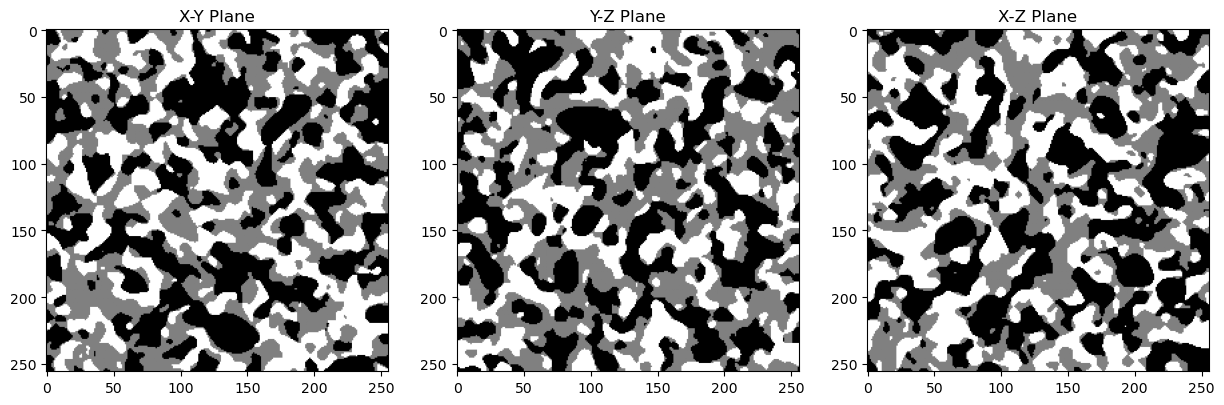

In [3]:
# Visualize the microstructure
x_mid = img.shape[0] // 2
y_mid = img.shape[1] // 2
z_mid = img.shape[2] // 2

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img[x_mid, :, :], cmap='gray')
ax[0].set_title('X-Y Plane')
ax[1].imshow(img[:, y_mid, :], cmap='gray')
ax[1].set_title('Y-Z Plane')
ax[2].imshow(img[:, :, z_mid], cmap='gray')
ax[2].set_title('X-Z Plane')
plt.show()

The first feature which is easy to measure while so important is $\varepsilon_i$ different phases. One thing that is good to mention here is that for our case of generating microstructure, it is better to use the total volume fraction feature rather than the percolating fraction. The reason is that, the percolation parameter is not controllable by the manufacturers and we know that really working samples have percolating fraction almost 90% of the total fraction $\varepsilon_i$. Also, as this percolation is somehow random, it would be better to model learn to capture it based on the real samples that we are using for our training dataset. This will also be considered for other features to be extracted.

In [43]:
# calculate volume fraction of each phase
vf = volume_fraction(img)
print(f"Volume fraction: {vf}")
print(vf['1'])
arr = np.array(list(vf.values()))
print(arr)

Volume fraction: {'0': 0.36226338148117065, '1': 0.33803582191467285, '2': 0.2997007966041565}
0.33803582191467285
[0.36226338 0.33803582 0.2997008 ]


The other feature shall be each phase tortuosity $\tau_i$. This is done by the tau.solver function in the taufactor library. Two things to mention here:

1- Is it neccessary to calculate tortuosity in 3 different directions and then do the averaging, or one direction would be enough? I believe 1 direction would be enough in our case for two reasons, a) the physical transport and calculations mainly considered to be dominated in the main direction (like x) so one direction calculation is enough. And b) As long as the same feature extraction method (like in 1 direction) is used for all the images and sub-volumes, I think it would make no difference. Besides, for the sake of computational expences it is favorable to use 1 direction dermination.

2- the tortuosity solver here can be only used for binary microstucture not ternary as we. Therefore, a for loop is considered to calculate all three phases tortuosity in one direction.

In [5]:
tortuosity = np.zeros(3)
for i in range(3):
    s = tau.Solver(img==i)
    s.solve()
    tortuosity[i] = s.tau.item()

print(f"Tortuosity of phases: {tortuosity}")

converged to: 4.257818222045898                   after: 901 iterations in: 10.3604                    seconds at a rate of 0.0115 s/iter
converged to: 3.4463417530059814                   after: 901 iterations in: 10.3042                    seconds at a rate of 0.0114 s/iter
converged to: 3.7110748291015625                   after: 1001 iterations in: 11.4467                    seconds at a rate of 0.0114 s/iter
Tortuosity of phases: [4.25781822 3.44634175 3.71107483]


TPB density is another important feature that can be only defined in the ternary microstrucutre as we have. It is the total lenght of the intersection of the three phases devided by the total volume of the sample. It is actully representing the active region that reaction can take place. It should be noted that the function for TPB calculation need the microstructure values to be float rather than integer. Also, as the document said that the returned value would be "the triple phase edges with respect to the total number of edges" and it is not total clear for me, thus I will create a simple geometry (2 blocks in a domain) to verfy its calculation and the nesseccary modification that might be needed.

Text(0.5, 1.0, 'Test Geometry Slice at z=50')

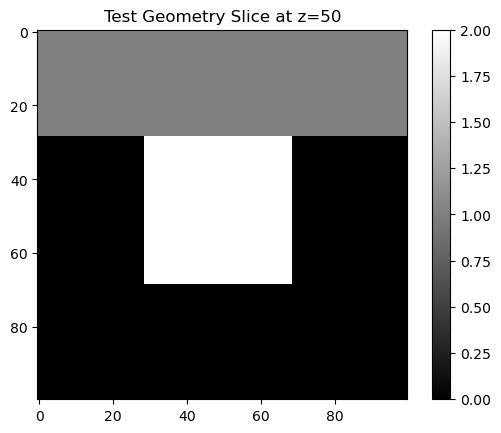

In [6]:
# creating the simple geometry for testing
img_test = np.zeros((100, 100, 100), dtype=np.float32)
img_test[0:29, :, :] = 1.0
img_test[29:69, 29:69, 29:69] = 2.0

# plot the slice of the test geometry
plt.imshow(img_test[:, :, 50], cmap='gray')
plt.colorbar()
plt.title('Test Geometry Slice at z=50')


In [7]:
tpb_test = triple_phase_boundary(img_test.astype(np.float32))
print(f"Triple phase boundary: {tpb_test}")

2940300
Triple phase boundary: 5.441621760837734e-05


We know that the real TPB curve in our test_img is 4 times of the edge lenght of cube (material == 2) which is 160 voxels. The total number of edges can be formulated as $x(y-1)(z-1) + (x-1)y(z-1) + (x-1)(y-1)z$. For our system of $N=100$ the total edge lenght would be $2940300$. The ratio of TPB lenght by the total edge lenght is the number that is reported by this function. Although, this number is slightly different of TPB lenght over the total volume, but we can accept this and continue with it as the TPB density in our calculations. One important note to be made here, is that TPB density is the first morphological feature so far that has dimension of $m/m^3$, therefore it is essentioal to take into account the resolution of the image (i.e., Res = 0.1 $\mu m$/voxel).

In [8]:
# microstructure tpb_density calculation
Res = 0.1 # microns per voxel
tpb_density = triple_phase_boundary(img.astype(np.float32)) / Res**2  # convert to per micron squared
print(f"Triple phase boundary per micron squared: {tpb_density}")

49939200
Triple phase boundary per micron squared: 0.9772984385490417


Specific surface area can be calculated as another morphological feature. It is the total surface of each phase over the total volume. It is calculated based on the phase-field (diffuse interface) method (https://doi.org/10.1149/1945-7111/ad9a07). To make its dimension accrate, it should be devided by Res.

In [9]:
ssa = specific_surface_area(img)
print(f"Specific surface area: {ssa}")
print(ssa['1']/Res)

Specific surface area: {'0': 0.10332829505205154, '1': 0.13004106283187866, '2': 0.10903912782669067}
1.3004106283187866


The final attribute is mean pore/particle diameter $r_{p,i}$. It is not that easy to extract. The "pore_size_distribution" function in the porespy is a bit expensive, so I decieded to use "chord_length". Becausing for claculating the chords we need to input a binary matrix we will do it in a for loop over all the materials. One other important thing is that the chord_length calculation will give up a distribution. Based on the previous readings, probably the distribution should look like a log-normal distribution rather than normal. See figures below. This will use to calculate the mean and the standard deviation of the distribution and report it.

The mean diameter of phase 0 = 13.297765044568553 voxels, while emprical mean = 12.809839925849847 voxels and the stereology diameter is 14.02378240340386 voxels
The mean diameter of phase 1 = 8.116116190429798 voxels, while emprical mean = 7.707495762644744 voxels and the stereology diameter is 10.397817875472045 voxels
The mean diameter of phase 2 = 10.250252890767205 voxels, while emprical mean = 10.017890750249773 voxels and the stereology diameter is 10.994247755925118 voxels


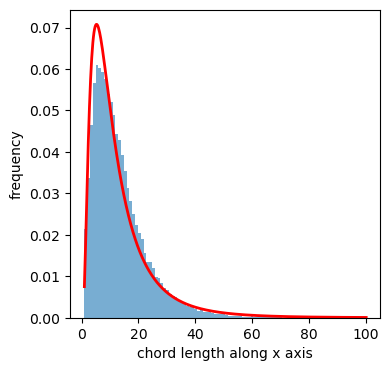

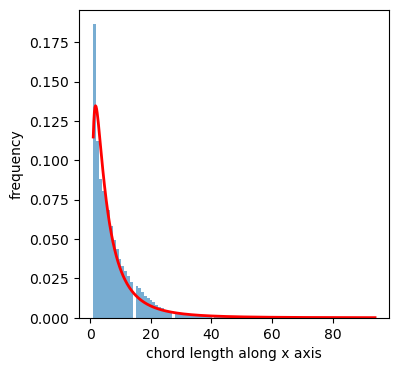

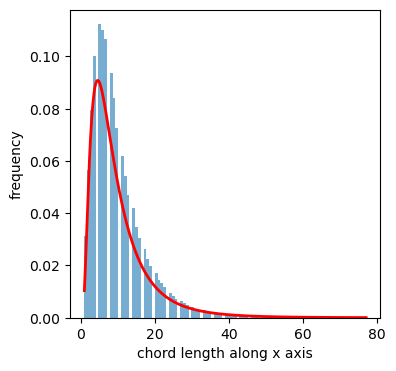

In [ ]:
r_p = np.zeros(3)
for i in range(3):
    chords = ps.filters.apply_chords_3D(img==i)
    chord_length = ps.metrics.chord_counts(im=chords)
    shape, loc, scale = lognorm.fit(chord_length, floc=0)
    sigma = shape          # this is σ
    mu = np.log(scale)     # this is μ
    r_p[i] = np.exp(mu + 0.5 * sigma**2)
    print(f"The mean diameter of phase {i} = {r_p[i]} voxels, while emprical mean = {chord_length.mean()} voxels and the stereology diameter is {4*vf[str(i)]/ssa[str(i)]} voxels")
    fig, ax = plt.subplots(1, 1, figsize=[4, 4])
    ax.hist(chord_length, bins=100, density=True, alpha=0.6)
    x = np.linspace(chord_length.min(), chord_length.max(), 500)
    pdf = lognorm.pdf(x, sigma, loc=0, scale=scale)
    ax.plot(x, pdf, 'r-', lw=2)
    plt.xlabel("chord length along x axis") 
    plt.ylabel("frequency");


Based on the above results, I think the log mean is good, it is between the stereology and the mean one.
Now it's time to check the written function.

In [49]:
from utils.feature_extraction import image_attribute_extraction

vf, ssa, tpb, tortuosity, r_p = image_attribute_extraction(img, Res=0.1)

print(vf)
print(ssa)
print(tpb)
print(tortuosity)
print(r_p)


49939200
converged to: 4.257818222045898                   after: 901 iterations in: 10.3622                    seconds at a rate of 0.0115 s/iter
converged to: 3.4463417530059814                   after: 901 iterations in: 10.3034                    seconds at a rate of 0.0114 s/iter
converged to: 3.7110748291015625                   after: 1001 iterations in: 11.4476                    seconds at a rate of 0.0114 s/iter
[0.36226338 0.33803582 0.2997008 ]
[1.03328295 1.30041063 1.09039128]
tensor(0.9773)
[4.25781822 3.44634175 3.71107483]
[1.3297765  0.81161162 1.02502529]
